In [1]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


In [2]:
iris = datasets.load_iris()
X  = iris["data"][:,(2,3)]
y = (iris["target"]==2).astype(np.float64)

In [6]:
#creating the linear Svc
input = (
    ("scaler",StandardScaler()),
    ("linearsvc",LinearSVC(C=1,loss='hinge'))
)
lin_svc = Pipeline(input)

In [7]:
lin_svc.fit(X,y)

Pipeline(steps=[('sclaer', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, loss='hinge'))])

In [8]:
lin_svc.predict([[5.3,1.9]])

array([1.])

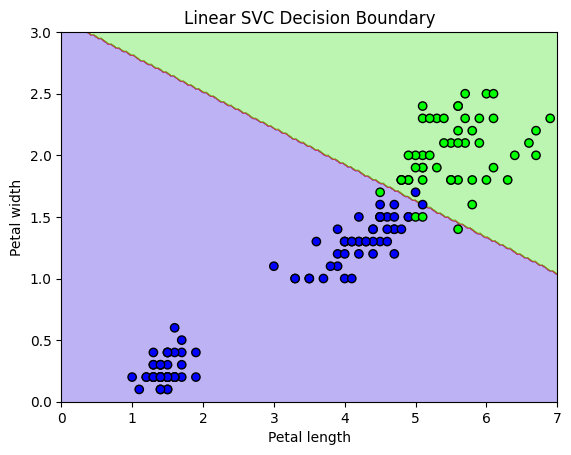

In [9]:
import matplotlib.pyplot as plt

def graph(model, X, y):
    x0 = np.linspace(0, 7, 200)
    x1 = np.linspace(0, 3, 200)
    x0, x1 = np.meshgrid(x0, x1)

    X_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = model.predict(X_new)
    y_pred = y_pred.reshape(x0.shape)

    # plot decision boundary
    plt.contourf(x0, x1, y_pred, alpha=0.3, cmap=plt.cm.brg)

    # plot data points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.brg, edgecolors='k')

    plt.xlabel("Petal length")
    plt.ylabel("Petal width")
    plt.title("Linear SVC Decision Boundary")
    plt.show()

graph(lin_svc,X,y)


In [15]:
#maing the polynolmiak
from sklearn.preprocessing import PolynomialFeatures
Input = ([
    ('polynomial_fet',PolynomialFeatures(degree=3)),
    ("scaler",StandardScaler()),
    ("linearsvc",LinearSVC(C=10,loss='hinge'))
])

In [16]:
polysvc = Pipeline(Input)
polysvc.fit(X,y)

Pipeline(steps=[('polynomial_fet', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=10, loss='hinge'))])

In [17]:
polysvc.predict([[5.7,1.3]])

array([1.])

In [30]:
#rbf
from sklearn.svm import SVC
rbf_svc = Pipeline([
    ("scaler",StandardScaler()),
    ("rbf_svc",SVC(kernel='rbf',gamma=1,C=0.001))
])
rbf_svc.fit(X,y)
rbf_svc.predict([[5.7,1.3]])

array([0.])